<a href="https://colab.research.google.com/github/RoyalRahul15/My-Dev/blob/main/Machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [2]:
medical_df = pd.read_csv('/content/sample_data/medical-charges.csv')

In [3]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
medical_df.age.describe()

,age
count,1338.000000
mean,39.207025
std,14.049960
min,18.000000
25%,27.000000
50%,39.000000
75%,51.000000
max,64.000000


Body Mass Index

In [7]:
fig = px.histogram(medical_df,
                   x='bmi',
                   marginal='box',
                   color_discrete_sequence=['red'],
                   title='Distribution of BMI')
fig.update_layout(bargap=0.2)
fig.show()

Annual Medical Charges

In [9]:
fig = px.histogram(medical_df,
                   x='charges',
                   marginal='box',
                   color='smoker',

                   color_discrete_sequence=['green','grey'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.2)
fig.show()

medica

In [10]:
medical_df.smoker.value_counts()


,count
smoker,
no,1064
yes,274


In [11]:
medical_df['sex'].value_counts()

,count
sex,
male,676
female,662


In [14]:
px.histogram(medical_df,x='smoker',color='sex',title='Smoker')

In [15]:
medical_df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [16]:
fig = px.scatter(medical_df,
                 x='bmi',
                 y='charges',
                 color='smoker',
                 opacity=0.7,
                 hover_data=['sex'],
                 title='BMI vs charges')
fig.update_traces(marker_size=5)
fig.show()

In [17]:
medical_df['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


In [19]:
px.violin(medical_df,x='children',y='charges')

In [20]:
medical_df.age.corr(medical_df.charges)

np.float64(0.29900819333064754)

In [21]:
medical_df.bmi.corr(medical_df.charges)

np.float64(0.19834096883362895)

In [24]:
medical_df.smoker

,smoker
0,yes
1,no
2,no
3,no
4,no
...,...
1333,no
1334,no
1335,no
1336,no


In [23]:
smoker_values = {'yes':1,'no':0}
smoker_numeric = medical_df.smoker.map(smoker_values)
smoker_numeric

,smoker
0,1
1,0
2,0
3,0
4,0
...,...
1333,0
1334,0
1335,0
1336,0


In [33]:
sex_values = {'female': 0, 'male': 1}
medical_df['sex_numeric'] = medical_df['sex'].map(sex_values)

In [34]:
print("Original 'sex' column value counts:")
print(medical_df['sex'].value_counts())

print("\n'sex_numeric' column value counts:")
print(medical_df['sex_numeric'].value_counts())

Original 'sex' column value counts:
sex
male      676
female    662
Name: count, dtype: int64

'sex_numeric' column value counts:
sex_numeric
1    676
0    662
Name: count, dtype: int64


In [35]:
medical_df.corr(numeric_only=True)

,age,bmi,children,charges,sex_numeric
age,1.000000,0.109272,0.042469,0.299008,-0.020856
bmi,0.109272,1.000000,0.012759,0.198341,0.046371
children,0.042469,0.012759,1.000000,0.067998,0.017163
charges,0.299008,0.198341,0.067998,1.000000,0.057292
sex_numeric,-0.020856,0.046371,0.017163,0.057292,1.000000


In [ ]:
medical_df.corr(numeric_only=True)

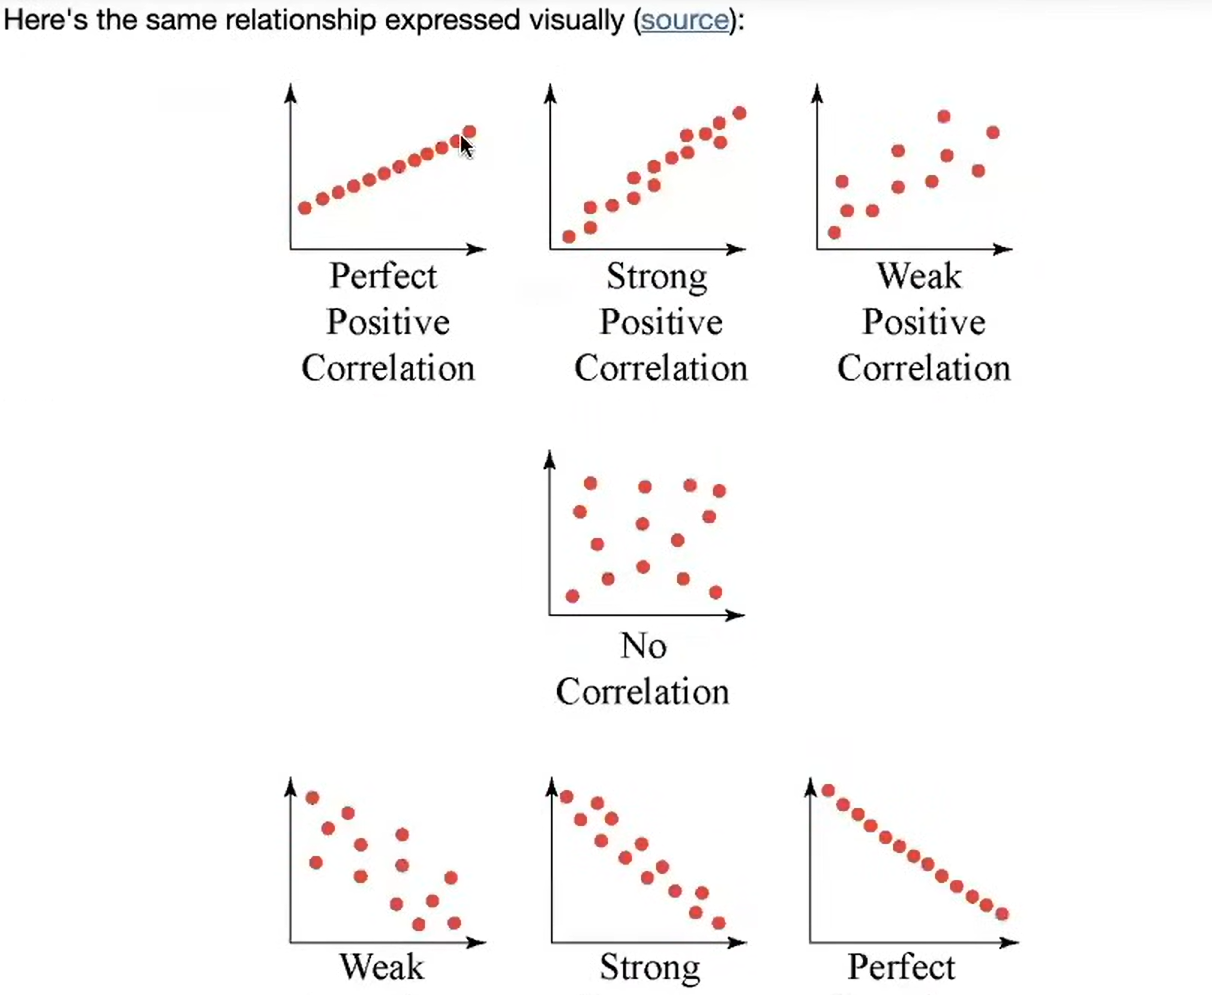

Model

charges = w*age +b

In [36]:
def estimates_charges(age,w,b):
  return w * age + b

In [37]:
w = 50
b = 100

In [38]:
estimates_charges(50,w,b)

2600

In [39]:
non_smoker_df = medical_df[medical_df.smoker == 'no']
display(non_smoker_df.head())

,age,sex,bmi,children,smoker,region,charges,sex_numeric
1,18,male,33.770,1,no,southeast,1725.55230,1
2,28,male,33.000,3,no,southeast,4449.46200,1
3,33,male,22.705,0,no,northwest,21984.47061,1
4,32,male,28.880,0,no,northwest,3866.85520,1
5,31,female,25.740,0,no,southeast,3756.62160,0


In [40]:
ages = non_smoker_df.age

In [41]:
fig = px.histogram(non_smoker_df, x='age', marginal='box', title='Distribution of Ages for Non-Smokers', color_discrete_sequence=['blue'])
fig.update_layout(bargap=0.2)
fig.show()

In [43]:
fig = px.scatter(non_smoker_df,
                 x='age',
                 y='charges',
                 title='Age vs. Charges for Non-Smokers',
                 hover_data=['sex', 'bmi', 'children'],
                 color_discrete_sequence=['purple'])
fig.update_traces(marker_size=5)
fig.show()

In [44]:
from sklearn.linear_model import LinearRegression

# Prepare the data for linear regression
X = non_smoker_df[['age']]
y = non_smoker_df['charges']

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Print the coefficients and intercept
print(f'Coefficient (slope): {model.coef_[0]:.2f}')
print(f'Intercept: {model.intercept_:.2f}')

Coefficient (slope): 267.25
Intercept: -2091.42


The linear regression model shows how 'charges' change with 'age' for non-smokers. The coefficient indicates the change in charges for each one-unit increase in age, while the intercept is the estimated charge when age is zero.

In [45]:
import plotly.express as px

# Add the regression line to the scatter plot
fig = px.scatter(non_smoker_df,
                 x='age',
                 y='charges',
                 title='Age vs. Charges for Non-Smokers with Regression Line',
                 hover_data=['sex', 'bmi', 'children'],
                 color_discrete_sequence=['purple'])

# Add the regression line
fig.add_trace(px.line(x=X['age'], y=model.predict(X),
                      color_discrete_sequence=['red']).data[0])

fig.update_traces(marker_size=5)
fig.show()